## Sentiment Analysis

Can we trust the review scores as indicators of customer sentiment toward the product?

To answer this question, a sentiment analysis is performed on the reviews, in order to understand the overall sentiment of the reviews and how it relates to the products and users. The sentiment analysis is performed using a pre-trained BERT model fine-tuned on the food reviews dataset. The model is then evaluated on a test set of 300 reviews, and the results are compared to the true labels.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
 
from transformers import pipeline, AutoTokenizer, AutoModel
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import plotly.express as px
import plotly.graph_objects as go
import torch
from pathlib import Path

c:\Users\elena\OneDrive\Desktop\UNI\DA\food-reviews-analysis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DATA_DIR  = Path('../data/processed')
MODEL_DIR = Path('../src/models/bert-reviews-tuned')
EMB_DIR   = DATA_DIR / 'wordviz_embeddings'
EMB_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
SAMPLE_SIZE  = 5000   # reviews for stratified inference

INT_TO_NAME  = {0: 'negative', 1: 'neutral', 2: 'positive'}
PALETTE      = {'negative': '#e05c5c', 'neutral': '#f0a500', 'positive': '#4caf82'}

### Model Evaluation on Test Set

Before using the model for business insights, we qualify its reliability.
The test set was held out during fine-tuning and never seen by the model.

In [3]:
test_df = pd.read_csv("../data/processed/test_data.csv").sample(frac=1, random_state=42).head(300)
model = pipeline("sentiment-analysis", model="../src/models/bert-reviews-tuned", tokenizer="../src/models/bert-reviews-tuned", truncation=True)
LABEL_MAP = {
    'LABEL_0': 0,
    'LABEL_1': 1,
    'LABEL_2': 2
}

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 2895.45it/s]


In [ ]:
TEST_RESULTS = DATA_DIR / 'test_results.csv'
 
if TEST_RESULTS.exists():
    test_df = pd.read_csv(TEST_RESULTS)
    print(f'Loaded existing results.')
else:
    raw_test = (
        pd.read_csv(DATA_DIR / 'test_data.csv')
        .sample(frac=1, random_state=RANDOM_STATE)
        .head(300)
    )
    model_pipe = pipeline(
        'sentiment-analysis',
        model=str(MODEL_DIR),
        tokenizer=str(MODEL_DIR),
        truncation=True,
        device=0 if torch.cuda.is_available() else -1
    )
    results = model_pipe(raw_test['text'].tolist(), batch_size=32)
    raw_test['pred_label'] = [LABEL_MAP[r['label']] for r in results]
    raw_test.to_csv(TEST_RESULTS, index=False)
    test_df = raw_test

Loaded existing test results (300 rows).


In [13]:
if test_df['pred_label'].dtype == object:
    test_df['pred_label'] = test_df['pred_label'].map(LABEL_MAP)

y_true = test_df['label'].astype(int)
y_pred = test_df['pred_label'].astype(int)

In [ ]:
print(f"Accuracy:        {accuracy_score(y_true, y_pred):.3f}")
print(f"Macro Precision: {precision_score(y_true, y_pred, average='macro'):.3f}")
print(f"Macro Recall:    {recall_score(y_true, y_pred, average='macro'):.3f}")
print(f"Macro F1:        {f1_score(y_true, y_pred, average='macro'):.3f}")
print()
print(classification_report(y_true, y_pred, target_names=CLASS_ORDER))

Accuracy:        0.863
Macro Precision: 0.656
Macro Recall:    0.621
Macro F1:        0.629

              precision    recall  f1-score   support

    negative       0.72      0.74      0.73        42
     neutral       0.33      0.17      0.22        24
    positive       0.91      0.96      0.94       234

    accuracy                           0.86       300
   macro avg       0.66      0.62      0.63       300
weighted avg       0.84      0.86      0.85       300



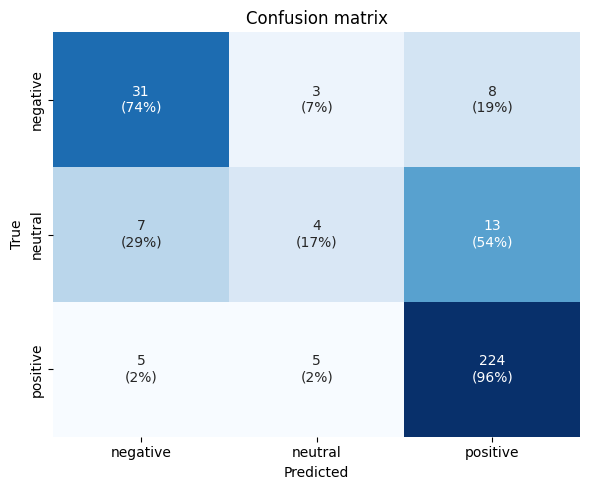

In [ ]:
CLASS_ORDER  = ['negative', 'neutral', 'positive']

cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
 
labels = np.array([
    [f'{cm[i,j]}\n({cm_norm[i,j]:.0%})' for j in range(3)]
    for i in range(3)
])
 
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_norm, annot=labels, fmt='', cmap='Blues', xticklabels=CLASS_ORDER, yticklabels=CLASS_ORDER, cbar=False)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion matrix')
plt.tight_layout()
plt.show()

## Agreement between Stars and BERT predictions

The central question is: when do numeric scores and predicted sentiment tell the same story and when don't they?

In [ ]:
test_df['agree'] = test_df['label'] == test_df['bert_label']
rate = test_df['agree'].mean()
 
print(f'Agreement rate:    {rate:.1%}')
print(f'  Matching:        {test_df["agree"].sum():,}')
print(f'  Diverging:       {(~test_df["agree"]).sum():,}')

In [ ]:
results_df = pd.DataFrame({
    'text': test_df['text'],
    'true_label': y_true,
    'pred_label': y_pred
})
misclassified = results_df[results_df['true_label'] != results_df['pred_label']]

pd.set_option('display.max_colwidth', 700)
print(misclassified.head(10))

An analysis of a sample of the misclassified reviews is performed, in order to understand the main reasons of the misclassification. To a fast inspection, it seems that the model misclassifies mainly reviews that are not clearly positive or negative, but rather neutral or mixed.  
  
For example some of them, like id 12374, are reviews that are positive about the product but negative about the delivery, or vice versa.  
Others, like id 31378, clearly express in the text which score they are giving, but mention a lot of other contrasting opinions (such as flavours they love and hate). This kind of reviews seems to have confused the model, which is not able to understand the overall sentiment of the review.

### Sentiment Explainability

In [ ]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer

model = AutoModelForSequenceClassification.from_pretrained('../src/models/bert-reviews-tuned', num_labels=3)
tokenizer = AutoTokenizer.from_pretrained('../src/models/bert-reviews-tuned')

from transformers_interpret import SequenceClassificationExplainer

cls_explainer = SequenceClassificationExplainer(
    model,
    tokenizer,
)
word_attributions = cls_explainer("This stuff is awful, cheap leaves and just not good. I've made better tea drying blackberry leaves! Stick to Liptons or Red Rose!!")
print(f'Predicted label {cls_explainer.predicted_class_index} aka {cls_explainer.predicted_class_name} label')
_ = cls_explainer.visualize()

In [ ]:
import shap
import transformers

# Carica il modello e il tokenizer
model = transformers.AutoModelForSequenceClassification.from_pretrained("../src/models/bert-reviews-tuned", num_labels=3)
tokenizer = transformers.AutoTokenizer.from_pretrained("../src/models/bert-reviews-tuned")

# Crea una pipeline di Hugging Face
pred_pipeline = transformers.pipeline("sentiment-analysis", model=model, tokenizer=tokenizer, return_all_scores=True)

# Crea l'explainer di SHAP
explainer = shap.Explainer(pred_pipeline)

# Esegui l'analisi su un esempio
text = ["This stuff is awful, cheap leaves and just not good. I've made better tea drying blackberry leaves! Stick to Liptons or Red Rose!!"]
shap_values = explainer(text)

# Visualizza
shap.plots.text(shap_values[0])